# Positional Encoding Toy Experiment

This notebook tests whether a **single attention layer** can learn to map a uniform token input to normalized $(x, y)$ coordinates.

We compare four positional encoding styles:
- Learned additive embeddings
- Fixed 2D sinusoidal additive embeddings
- RoPE (rotary) on $(q, k)$
- ALiBi attention bias

The key idea: if a positional method provides a useful positional bias, this toy objective should be easy to optimize.

In [17]:
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def set_seed(seed: int = 0):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [18]:
def build_2d_sincos_pos_embed(
    h: int,
    w: int,
    embed_dim: int,
    dtype,
    device,
    base_wavelength: int = 10_000,
) -> torch.Tensor:
    """Returns shape (1, h*w, embed_dim)."""
    assert embed_dim % 4 == 0, "embed_dim must be divisible by 4"

    grid_h = torch.arange(h, dtype=dtype, device=device)
    grid_w = torch.arange(w, dtype=dtype, device=device)
    y, x = torch.meshgrid(grid_h, grid_w, indexing="ij")

    y = y.reshape(-1)
    x = x.reshape(-1)

    dim_quarter = embed_dim // 4
    omega = torch.arange(dim_quarter, dtype=dtype, device=device)
    omega = 1.0 / (base_wavelength ** (omega / dim_quarter))

    out_y = y[:, None] * omega[None, :]
    out_x = x[:, None] * omega[None, :]

    emb_y = torch.cat([torch.sin(out_y), torch.cos(out_y)], dim=1)
    emb_x = torch.cat([torch.sin(out_x), torch.cos(out_x)], dim=1)

    pos_embed = torch.cat([emb_y, emb_x], dim=1)
    return pos_embed.unsqueeze(0)


def get_distance_matrix(
    n_tokens_h: int,
    n_tokens_w: int,
    n_reg_tokens: int = 0,
    metric: str = "euclidean",
    normalize: bool = True,
    wrap: bool = False,
    add_cls: bool = False,
    device: str | torch.device = "cpu",
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    coords = torch.stack(
        torch.meshgrid(
            torch.arange(n_tokens_h, device=device),
            torch.arange(n_tokens_w, device=device),
            indexing="ij",
        ),
        dim=-1,
    ).reshape(-1, 2)

    diff = coords.unsqueeze(1) - coords.unsqueeze(0)
    diff = diff.abs()

    if wrap:
        diff[..., 0] = torch.minimum(diff[..., 0], n_tokens_h - diff[..., 0])
        diff[..., 1] = torch.minimum(diff[..., 1], n_tokens_w - diff[..., 1])

    if metric == "euclidean":
        d = torch.sqrt((diff**2).sum(-1))
    elif metric == "manhattan":
        d = diff.sum(-1)
    else:
        raise ValueError("metric must be 'euclidean' or 'manhattan'")

    if normalize:
        d = d / d.max().clamp_min(1e-8)
    d = -d

    n_extra_tokens = int(add_cls) + n_reg_tokens
    d = F.pad(d, (n_extra_tokens, 0, n_extra_tokens, 0), mode="constant")
    return d.to(device=device, dtype=dtype)


def build_normalized_xy_grid(h: int, w: int, device: torch.device, dtype: torch.dtype = torch.float32):
    y = torch.linspace(0.0, 1.0, h, device=device, dtype=dtype)
    x = torch.linspace(0.0, 1.0, w, device=device, dtype=dtype)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    grid = torch.stack([xx, yy], dim=0).unsqueeze(0)  # (1, 2, H, W)
    return grid


def rotate_half(x: torch.Tensor) -> torch.Tensor:
    x1 = x[..., ::2]
    x2 = x[..., 1::2]
    x_rot = torch.stack((-x2, x1), dim=-1)
    return x_rot.flatten(-2)


def build_1d_rope_trig(
    positions: torch.Tensor,
    dim: int,
    base_wavelength: int = 10_000,
):
    """Returns cos/sin for one axis with shape (N, dim)."""
    assert dim % 2 == 0, "RoPE axis dim must be even"
    half = dim // 2
    omega = torch.arange(half, dtype=positions.dtype, device=positions.device)
    omega = 1.0 / (base_wavelength ** (omega / half))
    theta = positions[:, None] * omega[None, :]
    theta = torch.repeat_interleave(theta, repeats=2, dim=-1)
    return torch.cos(theta), torch.sin(theta)


def build_2d_rope_cache(
    h: int,
    w: int,
    head_dim: int,
    dtype: torch.dtype,
    device: torch.device,
    base_wavelength: int = 10_000,
):
    """
    Axial 2D RoPE cache.

    Splits head_dim into two halves: first half rotates with y positions,
    second half rotates with x positions.

    Returns cos, sin of shape (1, 1, H*W, head_dim).
    """
    assert head_dim % 4 == 0, "For axial 2D RoPE, head_dim must be divisible by 4"

    axis_dim = head_dim // 2

    grid_h = torch.arange(h, dtype=dtype, device=device)
    grid_w = torch.arange(w, dtype=dtype, device=device)
    yy, xx = torch.meshgrid(grid_h, grid_w, indexing="ij")
    yy = yy.reshape(-1)
    xx = xx.reshape(-1)

    y_cos, y_sin = build_1d_rope_trig(yy, axis_dim, base_wavelength=base_wavelength)
    x_cos, x_sin = build_1d_rope_trig(xx, axis_dim, base_wavelength=base_wavelength)

    cos = torch.cat([y_cos, x_cos], dim=-1).unsqueeze(0).unsqueeze(0)
    sin = torch.cat([y_sin, x_sin], dim=-1).unsqueeze(0).unsqueeze(0)
    return cos, sin


def apply_rope_2d(q: torch.Tensor, k: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor):
    q = q * cos + rotate_half(q) * sin
    k = k * cos + rotate_half(k) * sin
    return q, k


def get_alibi_slopes(num_heads: int, device: torch.device, mode: str = "fixed") -> torch.Tensor:
    if mode == "constant":
        slopes = torch.ones(num_heads, device=device)
    elif mode == "fixed":
        xs = (2**8) ** (1 / num_heads)
        slopes = torch.tensor([1 / xs ** (i + 1) for i in range(num_heads)], device=device)
    else:
        raise ValueError("mode must be 'fixed' or 'constant'")
    return slopes.view(num_heads, 1, 1)


def add_positional_encoding(x: torch.Tensor, pos: torch.Tensor | None):
    if pos is None:
        return x
    return x + pos

In [23]:
@dataclass
class ToyConfig:
    h: int = 14
    w: int = 14
    dim: int = 32
    num_heads: int = 6
    batch_size: int = 32
    base_wavelength: int = 10_000
    lr: float = 1e-3
    steps: int = 800
    log_every: int = 100


def gen_sample_mask(
    shape: tuple[int, int],
    step: int = 4,
    cutoff_frac: float = 1.0,
    random_mask: bool = False,
    device: torch.device | None = None,
) -> torch.Tensor:
    """Generate a spatial sampling mask over a top-left region with optional random sampling."""
    h, w = shape
    if step < 1:
        raise ValueError("step must be >= 1")
    if not (0.0 < cutoff_frac <= 1.0):
        raise ValueError("cutoff_frac must be in (0, 1]")

    mask = torch.zeros((h, w), dtype=torch.bool, device=device)
    y1 = max(1, int(h * cutoff_frac))
    x1 = max(1, int(w * cutoff_frac))

    if random_mask:
        n_total = y1 * x1
        n_samples = max(1, n_total // (step * step))
        inds = torch.randperm(n_total, device=device)[:n_samples]
        flat_mask = torch.zeros(n_total, dtype=torch.bool, device=device)
        flat_mask[inds] = True
        mask[:y1, :x1] = flat_mask.reshape(y1, x1)
    else:
        mask[:y1:step, :x1:step] = True

    return mask


class CustomAttentionBlock(nn.Module):
    """
    Single self-attention block configurable with one positional mode:
    - learned: additive learned token embedding
    - sincos: additive fixed 2D sinusoidal embedding
    - rope: rotary embedding on q,k
    - alibi: additive attention bias from pairwise distances
    """

    def __init__(self, cfg: ToyConfig, pos_mode: str, base_wavelength: int = 10_000):
        super().__init__()
        assert pos_mode in {"learned", "sincos", "rope", "alibi", "nope"}
        assert cfg.dim % cfg.num_heads == 0

        self.cfg = cfg
        self.pos_mode = pos_mode
        self.n = cfg.h * cfg.w
        self.head_dim = cfg.dim // cfg.num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(cfg.dim, 3 * cfg.dim)
        self.out_proj = nn.Linear(cfg.dim, 2)

        if pos_mode == "learned":
            self.pos_embed = nn.Parameter(torch.zeros(1, self.n, cfg.dim))
            nn.init.trunc_normal_(self.pos_embed, std=0.2)
        else:
            self.pos_embed = None

        if pos_mode == "sincos":
            pe = build_2d_sincos_pos_embed(
                cfg.h,
                cfg.w,
                cfg.dim,
                dtype=torch.float32,
                device=torch.device("cpu"),
                base_wavelength=base_wavelength,
            )
            self.register_buffer("sincos_embed", pe, persistent=False)
        else:
            self.sincos_embed = None

        if pos_mode == "rope":
            cos, sin = build_2d_rope_cache(
                cfg.h,
                cfg.w,
                self.head_dim,
                dtype=torch.float32,
                device=torch.device("cpu"),
                base_wavelength=base_wavelength,
            )
            self.register_buffer("rope_cos", cos, persistent=False)
            self.register_buffer("rope_sin", sin, persistent=False)
        else:
            self.rope_cos = None
            self.rope_sin = None

        if pos_mode == "alibi":
            d = get_distance_matrix(
                cfg.h,
                cfg.w,
                n_reg_tokens=0,
                add_cls=False,
                metric="euclidean",
                wrap=False,
                normalize=True,
                device="cpu",
            )
            self.register_buffer("alibi_distance", d, persistent=False)
            m = get_alibi_slopes(cfg.num_heads, device=torch.device("cpu"), mode="fixed")
            self.register_buffer("alibi_slopes", m, persistent=False)
        else:
            self.alibi_distance = None
            self.alibi_slopes = None

    def _move_runtime_buffers(self, x: torch.Tensor):
        if self.sincos_embed is not None and self.sincos_embed.device != x.device:
            self.sincos_embed = self.sincos_embed.to(device=x.device, dtype=x.dtype)
        if self.rope_cos is not None and self.rope_cos.device != x.device:
            self.rope_cos = self.rope_cos.to(device=x.device, dtype=x.dtype)
            self.rope_sin = self.rope_sin.to(device=x.device, dtype=x.dtype)
        if self.alibi_distance is not None and self.alibi_distance.device != x.device:
            self.alibi_distance = self.alibi_distance.to(device=x.device, dtype=x.dtype)
        if self.alibi_slopes is not None and self.alibi_slopes.device != x.device:
            self.alibi_slopes = self.alibi_slopes.to(device=x.device, dtype=x.dtype)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, n, c = x.shape
        assert n == self.n
        self._move_runtime_buffers(x)

        if self.pos_mode == "learned":
            x = add_positional_encoding(x, self.pos_embed)
        elif self.pos_mode == "sincos":
            x = add_positional_encoding(x, self.sincos_embed)

        qkv = self.qkv(x).view(b, n, 3, self.cfg.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        if self.pos_mode == "rope":
            q, k = apply_rope_2d(q, k, self.rope_cos, self.rope_sin)

        attn = (q * self.scale) @ k.transpose(-2, -1)

        if self.pos_mode == "alibi":
            bias = (self.alibi_slopes * self.alibi_distance).unsqueeze(0)
            attn = attn + bias

        attn = attn.softmax(dim=-1)
        out = attn @ v
        out = out.transpose(1, 2).reshape(b, n, c)
        out = self.out_proj(out)
        return out


class ToyCoordinatePredictor(nn.Module):
    def __init__(self, cfg: ToyConfig, pos_mode: str):
        super().__init__()
        self.cfg = cfg
        self.input_proj = nn.Linear(1, cfg.dim)
        self.attn = CustomAttentionBlock(cfg, pos_mode=pos_mode)
        self.head = nn.Sequential(nn.Identity())

    def forward(self, x_uniform_tokens: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(x_uniform_tokens)
        x = self.attn(x)
        pred = self.head(x)
        return pred

def to_numpy(t: torch.Tensor) -> np.ndarray:
    return t.detach().cpu().numpy()

def train_one_mode(pos_mode: str, cfg: ToyConfig, device: torch.device):
    model = ToyCoordinatePredictor(cfg, pos_mode=pos_mode).to(device)
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=0.0)

    grid = build_normalized_xy_grid(cfg.h, cfg.w, device=device)
    target_tokens = grid.flatten(2).transpose(1, 2)

    losses = []
    x_in = torch.rand(cfg.batch_size, cfg.h * cfg.w, 1, device=device)
    y = target_tokens.expand(cfg.batch_size, -1, -1)

    for step in range(1, cfg.steps + 1):
        pred = model(x_in)

        loss = F.l1_loss(pred, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        losses.append(float(loss.item()))
        if step % cfg.log_every == 0:
            print(f"[{pos_mode:7s}] step={step:4d} loss={loss.item():.6f}")

    model.eval()
    with torch.no_grad():
        pred_eval = model(x_in)

    pred_grid = pred_eval.transpose(1, 2).reshape(1, 2, cfg.h, cfg.w)
    return {
        "mode": pos_mode,
        # "model": model,
        "losses": losses,
        "final_loss": losses[-1],
        "input_grid": to_numpy(x_in[0, :, 0].reshape(cfg.h, cfg.w)),
        "target_grid": to_numpy(grid),
        "pred_grid": to_numpy(pred_grid),
    }, model

In [24]:

cfg = ToyConfig(h=50, w=50, dim=64, num_heads=4, batch_size=1, lr=5e-4, steps=1000, log_every=10)
results = {}
models = {}

# for mode in ["learned", "sincos", "rope", "alibi"]:
for mode in ["learned", "sincos", "rope", "alibi", "nope"]:
    print(f"\nTraining mode: {mode}")
    res, model = train_one_mode(mode, cfg, device=device)
    results[mode] = res
    models[mode] = model

print("\nFinal losses:")
for mode, res in results.items():
    print(f"{mode:7s}: {res['final_loss']:.6f}")


Training mode: learned
[learned] step=  10 loss=0.258321
[learned] step=  20 loss=0.265467
[learned] step=  30 loss=0.259528
[learned] step=  40 loss=0.255081
[learned] step=  50 loss=0.255720
[learned] step=  60 loss=0.255236
[learned] step=  70 loss=0.255071
[learned] step=  80 loss=0.255027
[learned] step=  90 loss=0.254996
[learned] step= 100 loss=0.254947
[learned] step= 110 loss=0.254864
[learned] step= 120 loss=0.254715
[learned] step= 130 loss=0.254431
[learned] step= 140 loss=0.253855
[learned] step= 150 loss=0.252602
[learned] step= 160 loss=0.249635
[learned] step= 170 loss=0.242371
[learned] step= 180 loss=0.226014
[learned] step= 190 loss=0.200753
[learned] step= 200 loss=0.183054
[learned] step= 210 loss=0.167850
[learned] step= 220 loss=0.157839
[learned] step= 230 loss=0.149413
[learned] step= 240 loss=0.142369
[learned] step= 250 loss=0.155768
[learned] step= 260 loss=0.141039
[learned] step= 270 loss=0.140709
[learned] step= 280 loss=0.132727
[learned] step= 290 loss

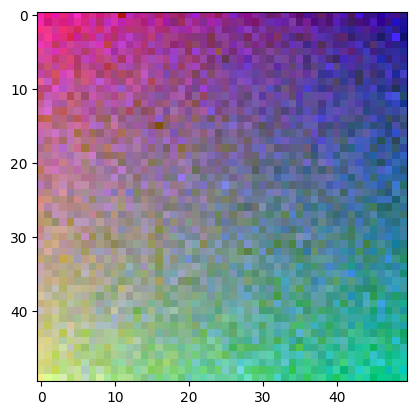

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale
trained_pos_enc_1D = models["learned"].attn.pos_embed.detach().cpu().numpy()
trained_pos_enc_2D = trained_pos_enc_1D[0].reshape(cfg.h, cfg.w, cfg.dim)

pcaed = PCA(n_components=3).fit_transform(trained_pos_enc_2D.reshape(-1, cfg.dim))
pcaed = minmax_scale(pcaed, feature_range=(0, 1), axis=0)
pcaed_grid = pcaed.reshape(cfg.h, cfg.w, 3)
plt.imshow(pcaed_grid)

In [15]:
import pickle

pickle.dump(results, open("th_toy_model_results.pkl", "wb"))

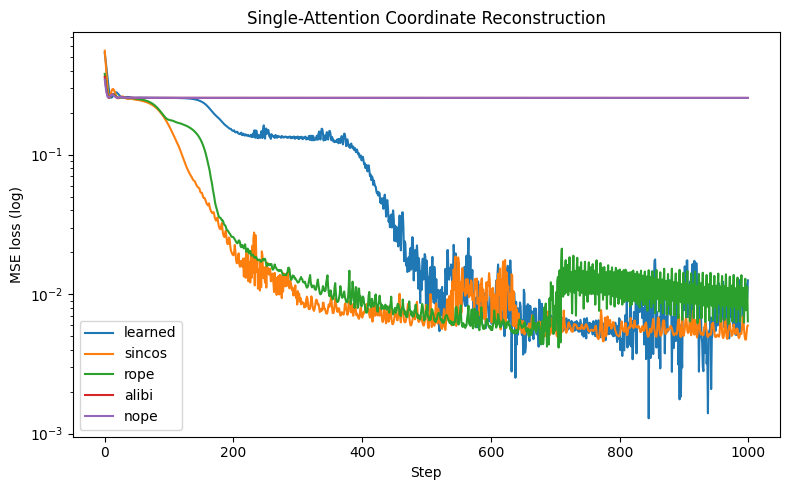

AttributeError: 'numpy.ndarray' object has no attribute 'clamp'

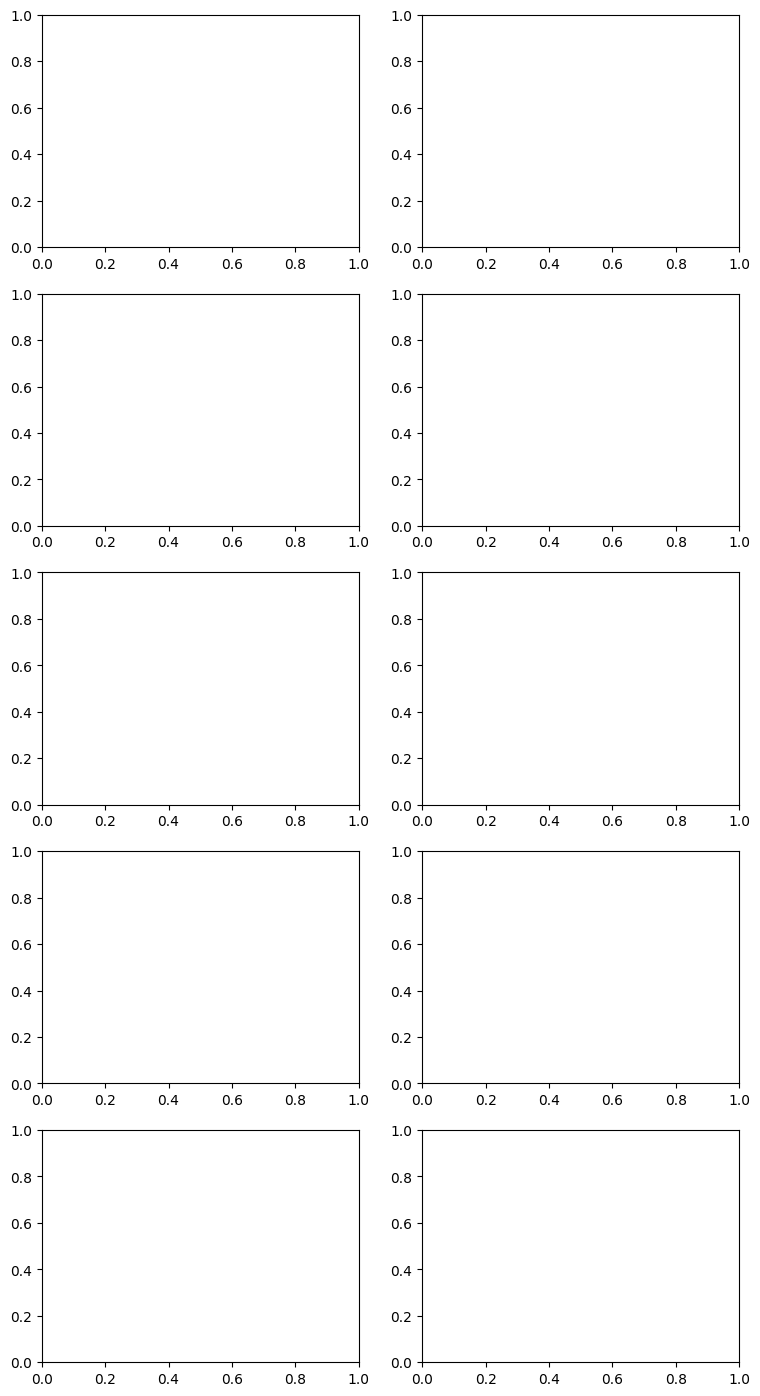

In [16]:
# Plot optimization curves
plt.figure(figsize=(8, 5))
for mode, res in results.items():
    plt.plot(res["losses"], label=mode)
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("MSE loss (log)")
plt.title("Single-Attention Coordinate Reconstruction")
plt.legend()
plt.tight_layout()
plt.show()


def xy_to_rb_rgb(xy_map: torch.Tensor) -> torch.Tensor:
    """Convert (2, H, W) map to RGB image with x->R, y->B."""
    if xy_map.ndim != 3 or xy_map.shape[0] != 2:
        raise ValueError("xy_map must have shape (2, H, W)")
    x = xy_map[0].clamp(0.0, 1.0)
    y = xy_map[1].clamp(0.0, 1.0)
    g = torch.zeros_like(x)
    return torch.stack([x, g, y], dim=-1)


def show_xy_rgb_pair(ax_target, ax_pred, target_xy: torch.Tensor, pred_xy: torch.Tensor, mode: str):
    """Render target/pred pair using x as red and y as blue channels."""
    target_rgb = xy_to_rb_rgb(target_xy).cpu().numpy()
    pred_rgb = xy_to_rb_rgb(pred_xy).cpu().numpy()

    ax_target.imshow(target_rgb)
    ax_target.set_title(f"{mode}: target (R=x, B=y)")
    ax_target.set_xticks([])
    ax_target.set_yticks([])

    ax_pred.imshow(pred_rgb)
    ax_pred.set_title(f"{mode}: pred (R=x, B=y)")
    ax_pred.set_xticks([])
    ax_pred.set_yticks([])


num_modes = len(results)
fig, axes = plt.subplots(num_modes, 2, figsize=(9, 3.5 * num_modes))
if num_modes == 1:
    axes = axes[None, :]

for r, (mode, res) in enumerate(results.items()):
    tgt = res["target_grid"][0]  # (2, H, W)
    pred = res["pred_grid"][0]   # (2, H, W)
    show_xy_rgb_pair(axes[r, 0], axes[r, 1], tgt, pred, mode)

plt.tight_layout()
plt.show()

In [ ]:
# plt.style.use("thesis.mplstyle")
# 2x7 summary figure with a spanning loss panel
fig = plt.figure(figsize=(7, 2.3))
W_SMALL = 0.6
gs = fig.add_gridspec(2, 7, width_ratios=[1, 1, W_SMALL, W_SMALL, W_SMALL, W_SMALL, W_SMALL])

# Loss plot spans first 2 rows and first 2 columns
loss_ax = fig.add_subplot(gs[:, :2])
for mode, res in results.items():
    loss_ax.plot(res["losses"], label=mode)
loss_ax.set_yscale("log")
loss_ax.set_xlabel("Step")
loss_ax.set_ylabel("L1 loss (log)")
loss_ax.set_title("Optimization Curves")
loss_ax.grid(alpha=0.2)
loss_ax.legend(fontsize=8)


def xy_to_rb_rgb(xy_map: torch.Tensor) -> torch.Tensor:
    if xy_map.ndim != 3 or xy_map.shape[0] != 2:
        raise ValueError("xy_map must have shape (2, H, W)")
    x = xy_map[0].clamp(0.0, 1.0)
    y = xy_map[1].clamp(0.0, 1.0)
    g = torch.zeros_like(x)
    return torch.stack([x, g, y], dim=-1)

# Top row, next 5 columns: random input + target ramp (+ 3 empty slots)
mode_order = ["learned", "sincos", "rope", "alibi", "nope"]
anchor_mode = next((m for m in mode_order if m in results), next(iter(results.keys())))
input_grid = results[anchor_mode]["input_grid"].cpu().numpy()
target_rgb = xy_to_rb_rgb(results[anchor_mode]["target_grid"][0]).cpu().numpy()

ax_input = fig.add_subplot(gs[0, 2])
ax_input.imshow(input_grid, cmap="gray")
ax_input.set_title("Random input")
ax_input.set_xticks([])
ax_input.set_yticks([])

ax_target = fig.add_subplot(gs[0, 3])
ax_target.imshow(target_rgb)
ax_target.set_title("Target ramp (R=x, B=y)")
ax_target.set_xticks([])
ax_target.set_yticks([])

for c in [4, 5, 6]:
    ax = fig.add_subplot(gs[0, c])
    ax.axis("off")

# Bottom row, next 5 columns: final predictions by positional encoding
for idx, mode in enumerate(mode_order):
    ax = fig.add_subplot(gs[1, 2 + idx])
    if mode in results:
        pred_rgb = xy_to_rb_rgb(results[mode]["pred_grid"][0]).cpu().numpy()
        ax.imshow(pred_rgb)
        ax.set_title(mode)
    else:
        ax.axis("off")
    ax.set_xticks([])
    ax.set_yticks([])

# plt.tight_layout()
# plt.show()
plt.savefig("th_toy_model_summary.pdf", bbox_inches="tight")
plt.close()